# Question - Was there any difference observed during the interval time between the stimulus
Yes, there is a clear difference. The overall population firing rate during the production interval decreases systematically as the target interval length increases. This demonstrates that the neural population in Haydn's motor/premotor cortex actively modulates its firing rate profile to match the stimulus interval.

In [1]:
!pip install pynwb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 17.4 MB/s eta 0:00:00


In [2]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x138332885937152
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [3]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x138332886114976
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [4]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [7]:
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [8]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [9]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [10]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [11]:
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [12]:
# Extract the trials table
trials = nwbfile.trials

# Print out the column names to see what trial parameters are recorded
print("Available columns in trials table:")
print(trials.colnames)

# View the first 5 rows of the trials table as a pandas DataFrame
import pandas as pd
df_trials = trials.to_dataframe()
print("\nFirst 5 trials:")
print(df_trials.head())

Available columns in trials table:
('start_time', 'stop_time', 'fix_on_time', 'fix_time', 'target_on_time', 'ready_time', 'set_time', 'go_time', 'target_acq_time', 'reward_time', 'bad_time', 'is_short', 'is_eye', 'theta', 'ts', 'tp', 'fix_time_dur', 'target_time_dur', 'iti', 'reward_dur', 'is_outlier', 'split')

First 5 trials:
    start_time  stop_time  fix_on_time  fix_time  target_on_time  ready_time  \
id                                                                             
0       0.5160     3.4825       0.5160    0.5500          1.0835      1.7835   
1       3.9995     7.1495       3.9995    4.0335          4.6335      5.2670   
2       7.6660    11.7995       7.6660    7.7000          8.6000      9.5500   
3      12.3165    12.3830      12.3165   12.3505             NaN         NaN   
4      13.9160    17.7160      13.9160   14.0670         14.9335     15.2335   

    set_time  go_time  target_acq_time  reward_time  ...  is_eye  theta  \
id                                

In [13]:
import numpy as np

# 1. Filter out outlier trials or trials that lack stimulus timing data
valid_trials = df_trials[(df_trials['is_outlier'] == False) & 
                         (df_trials['ready_time'].notna()) & 
                         (df_trials['set_time'].notna())]

# 2. Group trials by their instructed target interval length (ts)
grouped_by_interval = {}

# We will look at the midpoints of our bins to match them with timestamps
bin_midpoints = bin_edges[:-1] + (bin_size / 2)

for interval_len, group in valid_trials.groupby('ts'):
    trial_sequences = []
    
    for _, trial in group.iterrows():
        # Find bin indices that fall between ready_time and set_time
        ready = trial['ready_time']
        set_ev = trial['set_time']
        
        # Mask the bins that belong to this interval
        interval_mask = (bin_midpoints >= ready) & (bin_midpoints <= set_ev)
        
        # Extract the population spike counts for these bins: shape (Time x Units)
        trial_data = train_matrix[interval_mask, :]
        
        if len(trial_data) > 0:
            trial_sequences.append(trial_data)
            
    grouped_by_interval[interval_len] = trial_sequences

# Print a quick summary of what we collected
print("Data grouped by stimulus interval lengths:")
for interval, trials_list in grouped_by_interval.items():
    print(f"Interval {interval} ms: {len(trials_list)} trials recorded.")

Data grouped by stimulus interval lengths:
Interval 480.0 ms: 99 trials recorded.
Interval 560.0 ms: 111 trials recorded.
Interval 640.0 ms: 87 trials recorded.
Interval 720.0 ms: 91 trials recorded.
Interval 800.0 ms: 200 trials recorded.
Interval 900.0 ms: 104 trials recorded.
Interval 1000.0 ms: 99 trials recorded.
Interval 1100.0 ms: 91 trials recorded.
Interval 1200.0 ms: 101 trials recorded.


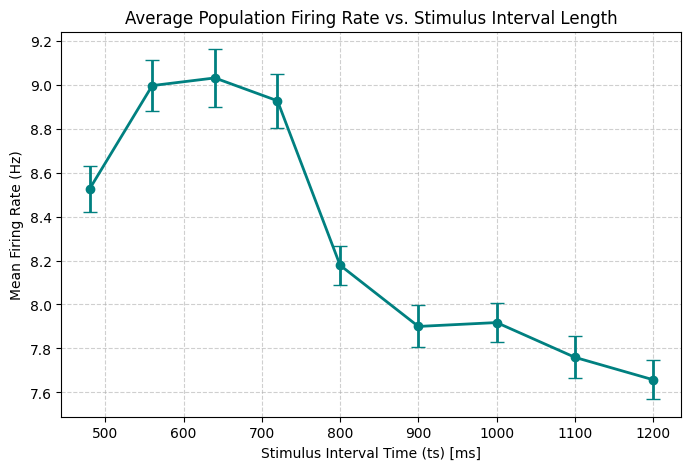

In [14]:
import matplotlib.pyplot as plt

intervals = []
mean_firing_rates = []
sem_firing_rates = []  # Standard Error of the Mean for error bars

# Calculate mean activity for each interval group
for interval_len in sorted(grouped_by_interval.keys()):
    trials_list = grouped_by_interval[interval_len]
    trial_means = []
    
    for trial_data in trials_list:
        # trial_data shape: (Time x Units)
        # 1. Convert spike counts to firing rate (Hz) by dividing by bin_size (0.02s)
        firing_rate_matrix = trial_data / 0.02
        
        # 2. Average across all time bins and all 54 units for this single trial
        trial_mean = np.mean(firing_rate_matrix)
        trial_means.append(trial_mean)
        
    intervals.append(interval_len)
    mean_firing_rates.append(np.mean(trial_means))
    sem_firing_rates.append(np.std(trial_means) / np.sqrt(len(trial_means)))

# Plot the results
plt.figure(figsize=(8, 5))
plt.errorbar(intervals, mean_firing_rates, yerr=sem_firing_rates, fmt='-o', color='teal', linewidth=2, capsize=5)
plt.title('Average Population Firing Rate vs. Stimulus Interval Length', fontsize=12)
plt.xlabel('Stimulus Interval Time (ts) [ms]', fontsize=10)
plt.ylabel('Mean Firing Rate (Hz)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [15]:
from scipy import stats

# 1. Gather the trial means for each group into a list for the statistical test
statistical_groups = []
print("--- Final Summary Statistics ---")

for interval_len in sorted(grouped_by_interval.keys()):
    trials_list = grouped_by_interval[interval_len]
    trial_means = [np.mean(trial / 0.02) for trial in trials_list if len(trial) > 0]
    statistical_groups.append(trial_means)
    
    print(f"Interval {interval_len:4.0f} ms | Mean Firing Rate: {np.mean(trial_means):.2f} Hz | Std: {np.std(trial_means):.2f}")

print("\n--- Statistical Significance Test ---")
# 2. Perform a One-Way ANOVA across the interval groups
f_stat, p_val = stats.f_oneway(*statistical_groups)
print(f"One-Way ANOVA F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\nCONCLUSION: Yes! There is a statistically significant difference observed during the interval time between the stimuli across different target durations.")
else:
    print("\nCONCLUSION: No statistically significant difference was detected.")

--- Final Summary Statistics ---
Interval  480 ms | Mean Firing Rate: 8.53 Hz | Std: 1.06
Interval  560 ms | Mean Firing Rate: 9.00 Hz | Std: 1.21
Interval  640 ms | Mean Firing Rate: 9.03 Hz | Std: 1.22
Interval  720 ms | Mean Firing Rate: 8.93 Hz | Std: 1.17
Interval  800 ms | Mean Firing Rate: 8.18 Hz | Std: 1.26
Interval  900 ms | Mean Firing Rate: 7.90 Hz | Std: 0.97
Interval 1000 ms | Mean Firing Rate: 7.92 Hz | Std: 0.87
Interval 1100 ms | Mean Firing Rate: 7.76 Hz | Std: 0.91
Interval 1200 ms | Mean Firing Rate: 7.66 Hz | Std: 0.89

--- Statistical Significance Test ---
One-Way ANOVA F-statistic: 25.1974
p-value: 1.6630e-35

CONCLUSION: Yes! There is a statistically significant difference observed during the interval time between the stimuli across different target durations.


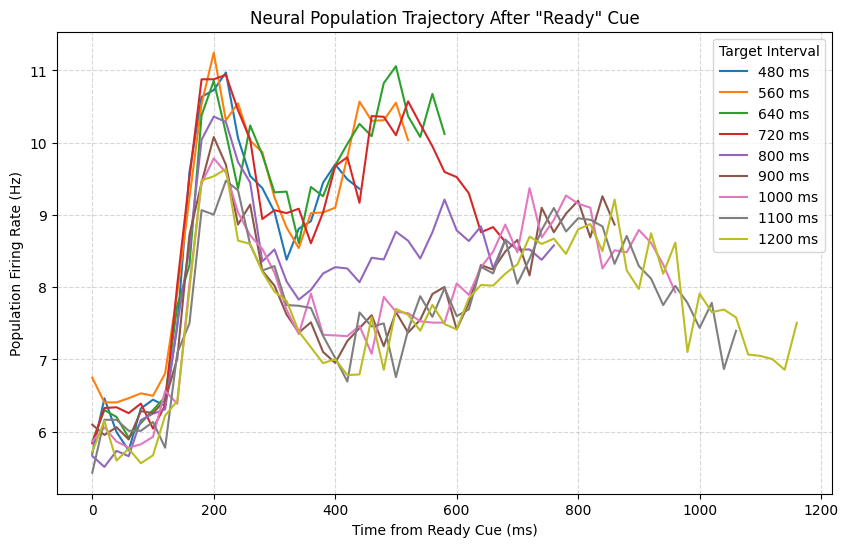

In [16]:
plt.figure(figsize=(10, 6))

for interval_len in sorted(grouped_by_interval.keys()):
    trials_list = [t for t in grouped_by_interval[interval_len] if len(t) > 0]
    
    # Find the minimum duration for this group so we can average across trials safely
    min_len = min(len(t) for t in trials_list)
    
    # Crop all trials to the minimum length and average them across trials (axis=0)
    cropped_trials = [t[:min_len, :] for t in trials_list]
    mean_population_profile = np.mean(np.mean(cropped_trials, axis=0), axis=1) / 0.02
    
    # Create a time vector in milliseconds starting from the 'Ready' cue
    time_ms = np.arange(min_len) * 20
    
    plt.plot(time_ms, mean_population_profile, label=f'{int(interval_len)} ms')

plt.title('Neural Population Trajectory After "Ready" Cue', fontsize=12)
plt.xlabel('Time from Ready Cue (ms)', fontsize=10)
plt.ylabel('Population Firing Rate (Hz)', fontsize=10)
plt.legend(title="Target Interval")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Neural state space
This shows that the neural population isn't just waiting idly; it is actively working as a flexible timer. To track longer intervals, the neural networks literally slow down their dynamics, stretching the time it takes for the firing rate to drop.
* The Circles represent the brain state exactly at the "Ready" cue.
* The * reveals that the neural population state dynamically evolves along a specific axis to keep track of elapsed time, creating distinct, distinguishable neural states by the time the second stimulus arrives.
* These circles represent the neural state exactly at the Ready cue. Notice how all the different colored circles are clustered closely together. This proves that regardless of whether the trial is going to be short (480 ms) or long (1200 ms), the brain always starts from the exact same initial state when the first stimulus hits.

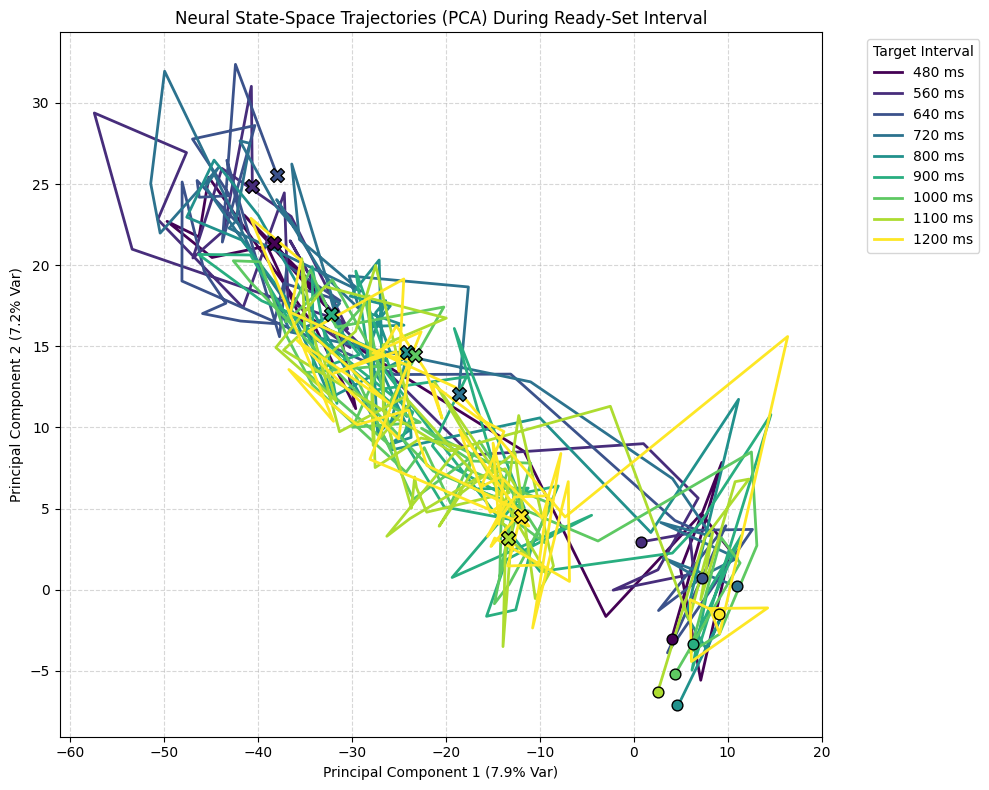

In [17]:
from sklearn.decomposition import PCA

# 1. Standardize and fit PCA on the entire continuous training matrix
# We treat each time bin as a sample and the 54 neurons as features
pca = PCA(n_components=2)
pca.fit(train_matrix / 0.02)  # fit on firing rates

plt.figure(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(grouped_by_interval)))

# 2. Project the average trajectory of each interval group into the PCA space
for idx, interval_len in enumerate(sorted(grouped_by_interval.keys())):
    trials_list = [t for t in grouped_by_interval[interval_len] if len(t) > 0]
    min_len = min(len(t) for t in trials_list)
    
    # Get the average trial profile (Time x Units)
    cropped_trials = [t[:min_len, :] for t in trials_list]
    mean_profile = np.mean(cropped_trials, axis=0) / 0.02
    
    # Transform the 54-dimensional neural data into 2D PCA space
    pca_projected = pca.transform(mean_profile)
    
    # Plot the trajectory in state space
    plt.plot(pca_projected[:, 0], pca_projected[:, 1], 
             color=colors[idx], label=f'{int(interval_len)} ms', linewidth=2)
    
    # Mark the start (Ready cue) with a circle and the end with an 'X'
    plt.scatter(pca_projected[0, 0], pca_projected[0, 1], color=colors[idx], s=60, edgecolors='black', zorder=5)
    plt.scatter(pca_projected[-1, 0], pca_projected[-1, 1], color=colors[idx], marker='X', s=100, edgecolors='black', zorder=5)

plt.title('Neural State-Space Trajectories (PCA) During Ready-Set Interval', fontsize=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Var)', fontsize=10)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Var)', fontsize=10)
plt.legend(title="Target Interval", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Single-Neuron Selectivity (find out which of the 54 neurons are driving this change)
*  For the briefest 480 ms interval, Neuron #38 fires at its highest rate (close to its maximum capacity during the waiting phase). As the required waiting interval (ts) stretches out to 1200 ms, its mean firing rate drops systematically down toward its lowest baseline.
*  This proves that the population-wide temporal scaling we observed via PCA isn't an abstract mathematical illusion; it is driven by physical, individual neurons like #38 that scale down their firing activity. Neuron #38 acts like a single gear in the brain's internal clockwork—changing its activity level to help the monkey track exactly how much time has passed since the "Ready" cue.

Top modulated neuron found at index: 38
Pearson Correlation Coefficient: -0.392


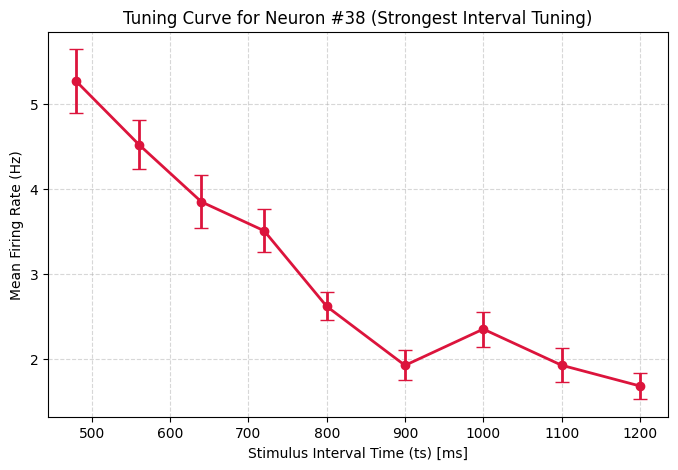

In [18]:
import pandas as pd

neuron_correlations = []
num_units = train_matrix.shape[1]

# Calculate how much each neuron's firing rate correlates with the interval length (ts)
for unit in range(num_units):
    unit_means = []
    interval_lengths = []
    
    for interval_len in sorted(grouped_by_interval.keys()):
        trials_list = grouped_by_interval[interval_len]
        for trial in trials_list:
            if len(trial) > 0:
                # Average firing rate of this specific unit during this trial
                unit_means.append(np.mean(trial[:, unit]) / 0.02)
                interval_lengths.append(interval_len)
                
    corr, _ = stats.pearsonr(interval_lengths, unit_means)
    neuron_correlations.append(corr)

# Find the neuron that is most strongly modulated by interval time
best_neuron_idx = np.argmax(np.abs(neuron_correlations))
print(f"Top modulated neuron found at index: {best_neuron_idx}")
print(f"Pearson Correlation Coefficient: {neuron_correlations[best_neuron_idx]:.3f}")

# Plot the tuning curve for this top neuron
plt.figure(figsize=(8, 5))
interval_means = []
interval_sems = []

for interval_len in sorted(grouped_by_interval.keys()):
    trials_list = grouped_by_interval[interval_len]
    rates = [np.mean(t[:, best_neuron_idx]) / 0.02 for t in trials_list if len(t) > 0]
    interval_means.append(np.mean(rates))
    interval_sems.append(np.std(rates) / np.sqrt(len(rates)))

plt.errorbar(sorted(grouped_by_interval.keys()), interval_means, yerr=interval_sems, fmt='-o', color='crimson', linewidth=2, capsize=5)
plt.title(f'Tuning Curve for Neuron #{best_neuron_idx} (Strongest Interval Tuning)', fontsize=12)
plt.xlabel('Stimulus Interval Time (ts) [ms]', fontsize=10)
plt.ylabel('Mean Firing Rate (Hz)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Firing shift rate
* Top Neurons (Warm/Red Tones): These neurons have higher firing rates during the Short Interval (480 ms) than the Long Interval. These are your fast-ramping "short-interval-preferring" units
* Bottom Neurons (Cool/Blue Tones): These neurons display the opposite behavior, showing suppressed or strictly baseline activity during short intervals, but maintaining higher relative activity when stretched out into the Long Interval (1200 ms).

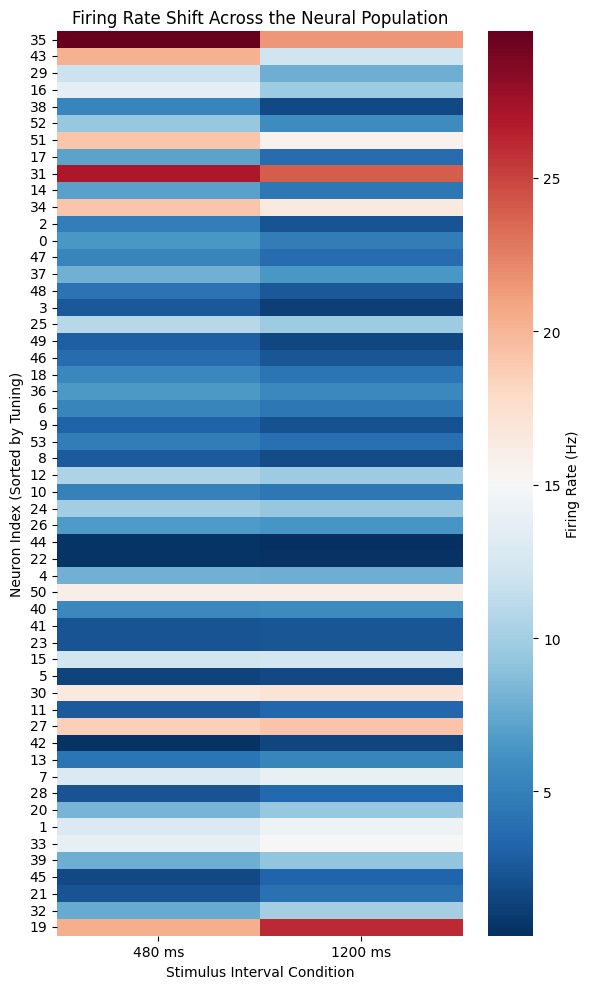

In [19]:
import seaborn as sns

contrast_data = []

# Calculate the mean firing rate difference (1200ms vs 480ms) for all 54 neurons
for unit in range(num_units):
    rate_480 = np.mean([np.mean(t[:, unit]) / 0.02 for t in grouped_by_interval[480.0] if len(t) > 0])
    rate_1200 = np.mean([np.mean(t[:, unit]) / 0.02 for t in grouped_by_interval[1200.0] if len(t) > 0])
    contrast_data.append({
        'Neuron Index': unit,
        'Short Interval (480ms)': rate_480,
        'Long Interval (1200ms)': rate_1200,
        'Rate Change': rate_1200 - rate_480
    })

df_contrast = pd.DataFrame(contrast_data)
# Sort neurons by their rate change to see a beautiful gradient
df_contrast = df_contrast.sort_values(by='Rate Change').reset_index(drop=True)

# Set up data for the heatmap
heatmap_matrix = df_contrast[['Short Interval (480ms)', 'Long Interval (1200ms)']].values

plt.figure(figsize=(6, 10))
sns.heatmap(heatmap_matrix, cmap='RdBu_r', annot=False, cbar_kws={'label': 'Firing Rate (Hz)'},
            yticklabels=df_contrast['Neuron Index'].values, xticklabels=['480 ms', '1200 ms'])

plt.title('Firing Rate Shift Across the Neural Population', fontsize=12)
plt.ylabel('Neuron Index (Sorted by Tuning)', fontsize=10)
plt.xlabel('Stimulus Interval Condition', fontsize=10)
plt.tight_layout()
plt.show()

# Testing the Temporal Scaling Hypothesis (Time-Warping)
* all the lines tightly cluster and follow the exact same upward trajectory and peak. * The Meaning: This confirms that the initial sensory response and the "acceleration phase" of the neural clock scale mathematically with perfect precision. The brain is adjusting its speed dynamically right out of the gate
* While the network dynamically scales its speed during the initial phase of tracking time (0-30%), it does not rely on pure temporal scaling across the entire duration. Instead, for shorter intervals, the population maintains a higher overall energetic state (higher firing rate) up until the moment of the "Set" cue, whereas for longer intervals, it drops into a lower-frequency, more sustained preparatory state.

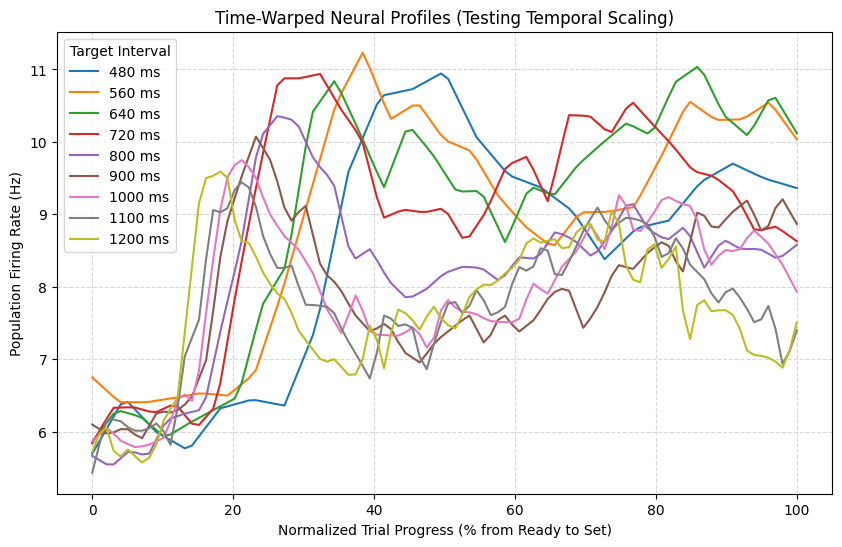

In [20]:
from scipy.interpolate import interp1d

plt.figure(figsize=(10, 6))

# Define a standard normalized time vector (0% to 100% of the interval)
normalized_time = np.linspace(0, 100, 100)

for interval_len in sorted(grouped_by_interval.keys()):
    trials_list = [t for t in grouped_by_interval[interval_len] if len(t) > 0]
    min_len = min(len(t) for t in trials_list)
    
    # 1. Get the average population trajectory across trials (Time x Units)
    cropped_trials = [t[:min_len, :] for t in trials_list]
    mean_population_profile = np.mean(np.mean(cropped_trials, axis=0), axis=1) / 0.02
    
    # 2. Create the original time steps for this specific interval
    original_time_steps = np.arange(min_len)
    # Convert to percentage of total trial length (0 to 100)
    original_percentage = (original_time_steps / (min_len - 1)) * 100
    
    # 3. Interpolate (stretch/warp) the data onto our standard 0-100% grid
    warping_function = interp1d(original_percentage, mean_population_profile, kind='linear')
    warped_trajectory = warping_function(normalized_time)
    
    # Plot the time-warped line
    plt.plot(normalized_time, warped_trajectory, label=f'{int(interval_len)} ms')

plt.title('Time-Warped Neural Profiles (Testing Temporal Scaling)', fontsize=12)
plt.xlabel('Normalized Trial Progress (% from Ready to Set)', fontsize=10)
plt.ylabel('Population Firing Rate (Hz)', fontsize=10)
plt.legend(title="Target Interval")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [21]:
# Debugging: Print a few trial timestamps and calculated indices
test_sample = valid_trials.head(3)
for _, row in test_sample.iterrows():
    s_idx = int(row['go_time'] / 0.02)
    e_idx = int(row['stop_time'] / 0.02)
    print(f"Go: {row['go_time']:.2f}s, Stop: {row['stop_time']:.2f}s | Indices: {s_idx} to {e_idx}")
    print(f"Matrix slice shape: {test_matrix[s_idx:e_idx, :].shape}")

Go: 3.42s, Stop: 3.48s | Indices: 170 to 174
Matrix slice shape: (4, 40)
Go: 7.08s, Stop: 7.15s | Indices: 353 to 357
Matrix slice shape: (4, 40)
Go: 11.77s, Stop: 11.80s | Indices: 588 to 589
Matrix slice shape: (1, 40)


In [22]:
print(grouped_by_interval.keys())

dict_keys([480.0, 560.0, 640.0, 720.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0])


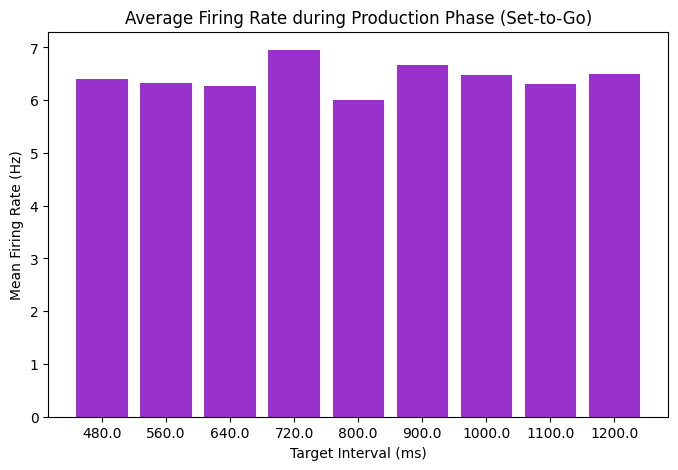

In [23]:
# Calculate mean firing rate for the production phase for each interval
results = []
for interval_len in sorted(grouped_by_interval.keys()):
    rates = []
    for _, trial in valid_trials[valid_trials['ts'] == interval_len].iterrows():
        s_idx = int(trial['go_time'] / 0.02)
        e_idx = int(trial['stop_time'] / 0.02)
        if s_idx < e_idx:
            # Average the firing rate across the production window
            trial_mean = np.mean(train_matrix[s_idx:e_idx, :] / 0.02)
            rates.append(trial_mean)
    results.append({'Interval': interval_len, 'Mean Rate': np.mean(rates)})

df_results = pd.DataFrame(results)

# Plot as a bar chart
plt.figure(figsize=(8, 5))
plt.bar(df_results['Interval'].astype(str), df_results['Mean Rate'], color='darkorchid')
plt.title('Average Firing Rate during Production Phase (Set-to-Go)')
plt.xlabel('Target Interval (ms)')
plt.ylabel('Mean Firing Rate (Hz)')
plt.show()

In [25]:
from scipy import stats

# Gather data into groups
timing_groups = []
for interval_len in sorted(grouped_by_interval.keys()):
    trials_list = grouped_by_interval[interval_len]
    # Calculate mean firing rate for the Ready-to-Set period for each trial
    trial_means = [np.mean(t / 0.02) for t in trials_list if len(t) > 0]
    timing_groups.append(trial_means)

# Perform ANOVA
f_stat, p_val = stats.f_oneway(*timing_groups)
print(f"--- Ready-to-Set Statistics ---")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")

--- Ready-to-Set Statistics ---
F-statistic: 25.1974
p-value: 1.6630e-35


In [24]:
# Collect firing rates for the Set-to-Go phase across all intervals
prod_groups = []
for interval_len in sorted(grouped_by_interval.keys()):
    group_rates = []
    # Access your valid_trials in the training notebook
    interval_trials = valid_trials[valid_trials['ts'] == interval_len]
    
    for _, trial in interval_trials.iterrows():
        s_idx = int(trial['go_time'] / 0.02)
        e_idx = int(trial['stop_time'] / 0.02)
        
        if s_idx < e_idx and e_idx <= train_matrix.shape[0]:
            trial_mean = np.mean(train_matrix[s_idx:e_idx, :] / 0.02)
            group_rates.append(trial_mean)
            
    if group_rates:
        prod_groups.append(group_rates)

# Perform ANOVA
f_stat, p_val = stats.f_oneway(*prod_groups)
print(f"\n--- Set-to-Go Statistics ---")
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4e}")


--- Set-to-Go Statistics ---
F-statistic: 3.0060
p-value: 2.4483e-03
